# ETCCDI Indices – Zarr Store Usage Example

Reads the consolidated zarr store and plots global **land-area weighted** annual
mean time series for all temperature and precipitation extremes indices across
**four models** and **three scenarios** (2035–2084).

**Zarr store layout:** `{model}/{scenario}/{index}`, dimensions `(member, year, lat, lon)`

| Model | SSP2-4.5 key | SAI key | HiLLA key |
|---|---|---|---|
| CESM2-WACCM | `SSP2-4.5` | `G6-1.5K-SAI` | `G6-1.5K-HiLLA` |
| E3SMv3 | `SSP245` | `G6-1.5K-SAI` | `G6-1.5K-HiLLA` |
| MIROC-ES2H | `baseline` | `G6-1.5K-SAI` | `G6-1.5K-HiLLA` |
| UKESM1-1 | `SSP245` | `G6-1.5K-SAI` | `G6-1.5K-HiLLA` |

> **Note:** All data span 2035–2084 except E3SMv3 / G6-1.5K-SAI (temperature only, 2035–2070).
> Shading shows the ensemble member spread (min–max); lines show the ensemble mean.


In [6]:
import numpy as np
import xarray as xr
import zarr
import s3fs
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

try:
    import regionmask
    HAS_REGIONMASK = True
except ImportError:
    HAS_REGIONMASK = False
    print("regionmask not found – computing global (land+ocean) mean instead of land-only.")


regionmask not found – computing global (land+ocean) mean instead of land-only.


In [7]:
ZARR_STORE = 's3://reflective-persistent-prod/alistairduffey/ETCCDI/ETCCDI_indices_annual.zarr'

# S3 filesystem (uses your default AWS credentials / instance role)
fs = s3fs.S3FileSystem(anon=False)

MODELS = ['CESM2-WACCM', 'E3SMv3', 'MIROC-ES2H', 'UKESM1-1']

# (zarr_key, display_label) pairs per model
MODEL_SCENARIOS = {
    'CESM2-WACCM': [('SSP2-4.5',      'SSP2-4.5'),
                    ('G6-1.5K-SAI',   'G6-1.5K-SAI'),
                    ('G6-1.5K-HiLLA', 'G6-1.5K-HiLLA')],
    'E3SMv3':      [('SSP245',         'SSP2-4.5'),
                    ('G6-1.5K-SAI',   'G6-1.5K-SAI'),
                    ('G6-1.5K-HiLLA', 'G6-1.5K-HiLLA')],
    'MIROC-ES2H':  [('baseline',       'SSP2-4.5'),
                    ('G6-1.5K-SAI',   'G6-1.5K-SAI'),
                    ('G6-1.5K-HiLLA', 'G6-1.5K-HiLLA')],
    'UKESM1-1':    [('SSP245',         'SSP2-4.5'),
                    ('G6-1.5K-SAI',   'G6-1.5K-SAI'),
                    ('G6-1.5K-HiLLA', 'G6-1.5K-HiLLA')],
}

SCENARIO_COLORS = {
    'SSP2-4.5':       '#555555',  # grey
    'G6-1.5K-SAI':    '#1976D2',  # blue
    'G6-1.5K-HiLLA':  '#D32F2F',  # red
}

# (zarr variable key, y-axis label)
TEMP_INDICES = [
    ('SU',  'Summer days\n(Tx>25\u00b0C, days yr\u207b\u00b9)'),
    ('ID',  'Ice days\n(Tx<0\u00b0C, days yr\u207b\u00b9)'),
    ('TXX', 'Max Tmax (\u00b0C)'),
    ('TXN', 'Min Tmax (\u00b0C)'),
    ('FD',  'Frost days\n(Tn<0\u00b0C, days yr\u207b\u00b9)'),
    ('TN',  'Tropical nights\n(Tn>20\u00b0C, days yr\u207b\u00b9)'),
    ('TNX', 'Max Tmin (\u00b0C)'),
    ('TNN', 'Min Tmin (\u00b0C)'),
]

PRECIP_INDICES = [
    ('PRCPTOT', 'Total precip\n(mm yr\u207b\u00b9)'),
    ('SDII',    'Daily intensity\n(mm wet-day\u207b\u00b9)'),
    ('RX1D',    'Rx1day (mm)'),
    ('RX5D',    'Rx5day (mm)'),
    ('CDD',     'Consec. dry days (days)'),
    ('CWD',     'Consec. wet days (days)'),
    ('R10MM',   'Heavy precip days\n(\u226510 mm, days yr\u207b\u00b9)'),
    ('R20MM',   'Very heavy precip\n(\u226520 mm, days yr\u207b\u00b9)'),
]


In [8]:
_land_mask_cache = {}

def get_land_mask(lat_vals, lon_vals):
    """Return an (nlat, nlon) float array: 1.0=land, 0.0=ocean."""
    key = (len(lat_vals), len(lon_vals))
    if key not in _land_mask_cache:
        if HAS_REGIONMASK:
            land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
            # mask(): 0 = land, NaN = ocean
            mask = land.mask(lon_vals, lat_vals)
            binary = (~np.isnan(mask.values)).astype(float)
        else:
            binary = np.ones((len(lat_vals), len(lon_vals)), dtype=float)
        _land_mask_cache[key] = binary
    return _land_mask_cache[key]


def load_land_ts(model, scenario_key, index):
    """
    Open zarr group {model}/{scenario_key}/{index} from S3 and return
    (years, ens_mean, ens_min, ens_max) as 1-D numpy arrays.
    Spatial mean is cos-lat area-weighted over land cells only.
    Returns None if the group or variable is unavailable.
    """
    s3_path = f"{ZARR_STORE}/{model}/{scenario_key}/{index}"
    try:
        mapper = fs.get_mapper(s3_path)
        ds = xr.open_zarr(mapper, consolidated=False)
    except Exception:
        return None
    if not ds.data_vars:
        return None

    da = ds[list(ds.data_vars)[0]]               # (member, year, lat, lon)

    land    = get_land_mask(da.lat.values, da.lon.values)   # (nlat, nlon)
    cos_lat = np.cos(np.deg2rad(da.lat.values))             # (nlat,)
    w = xr.DataArray(
        cos_lat[:, np.newaxis] * land,
        dims=['lat', 'lon'],
    )
    ts = da.weighted(w).mean(['lat', 'lon']).compute()       # (member, year)

    years    = ts.year.values
    ens_mean = ts.mean('member').values
    ens_min  = ts.min('member').values
    ens_max  = ts.max('member').values
    return years, ens_mean, ens_min, ens_max


In [9]:
print("Pre-loading temperature indices ...")
temp_cache = {}
for model in MODELS:
    for scen_key, _ in MODEL_SCENARIOS[model]:
        for idx, _ in TEMP_INDICES:
            k = (model, scen_key, idx)
            temp_cache[k] = load_land_ts(model, scen_key, idx)
            tag = '\u2713' if temp_cache[k] is not None else '\u2717 missing'
            print(f"  {model:<14s}  {scen_key:<16s}  {idx:<8s}  {tag}")

print("\nPre-loading precipitation indices ...")
precip_cache = {}
for model in MODELS:
    for scen_key, _ in MODEL_SCENARIOS[model]:
        for idx, _ in PRECIP_INDICES:
            k = (model, scen_key, idx)
            precip_cache[k] = load_land_ts(model, scen_key, idx)
            tag = '\u2713' if precip_cache[k] is not None else '\u2717 missing'
            print(f"  {model:<14s}  {scen_key:<16s}  {idx:<8s}  {tag}")

print("\nDone.")


Pre-loading temperature indices ...
  CESM2-WACCM     SSP2-4.5          SU        ✗ missing
  CESM2-WACCM     SSP2-4.5          ID        ✗ missing
  CESM2-WACCM     SSP2-4.5          TXX       ✗ missing
  CESM2-WACCM     SSP2-4.5          TXN       ✗ missing
  CESM2-WACCM     SSP2-4.5          FD        ✗ missing
  CESM2-WACCM     SSP2-4.5          TN        ✗ missing
  CESM2-WACCM     SSP2-4.5          TNX       ✗ missing
  CESM2-WACCM     SSP2-4.5          TNN       ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       SU        ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       ID        ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       TXX       ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       TXN       ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       FD        ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       TN        ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       TNX       ✗ missing
  CESM2-WACCM     G6-1.5K-SAI       TNN       ✗ missing
  CESM2-WACCM     G6-1.5K-HiLLA     SU        ✗ missing
  CESM2-WACC

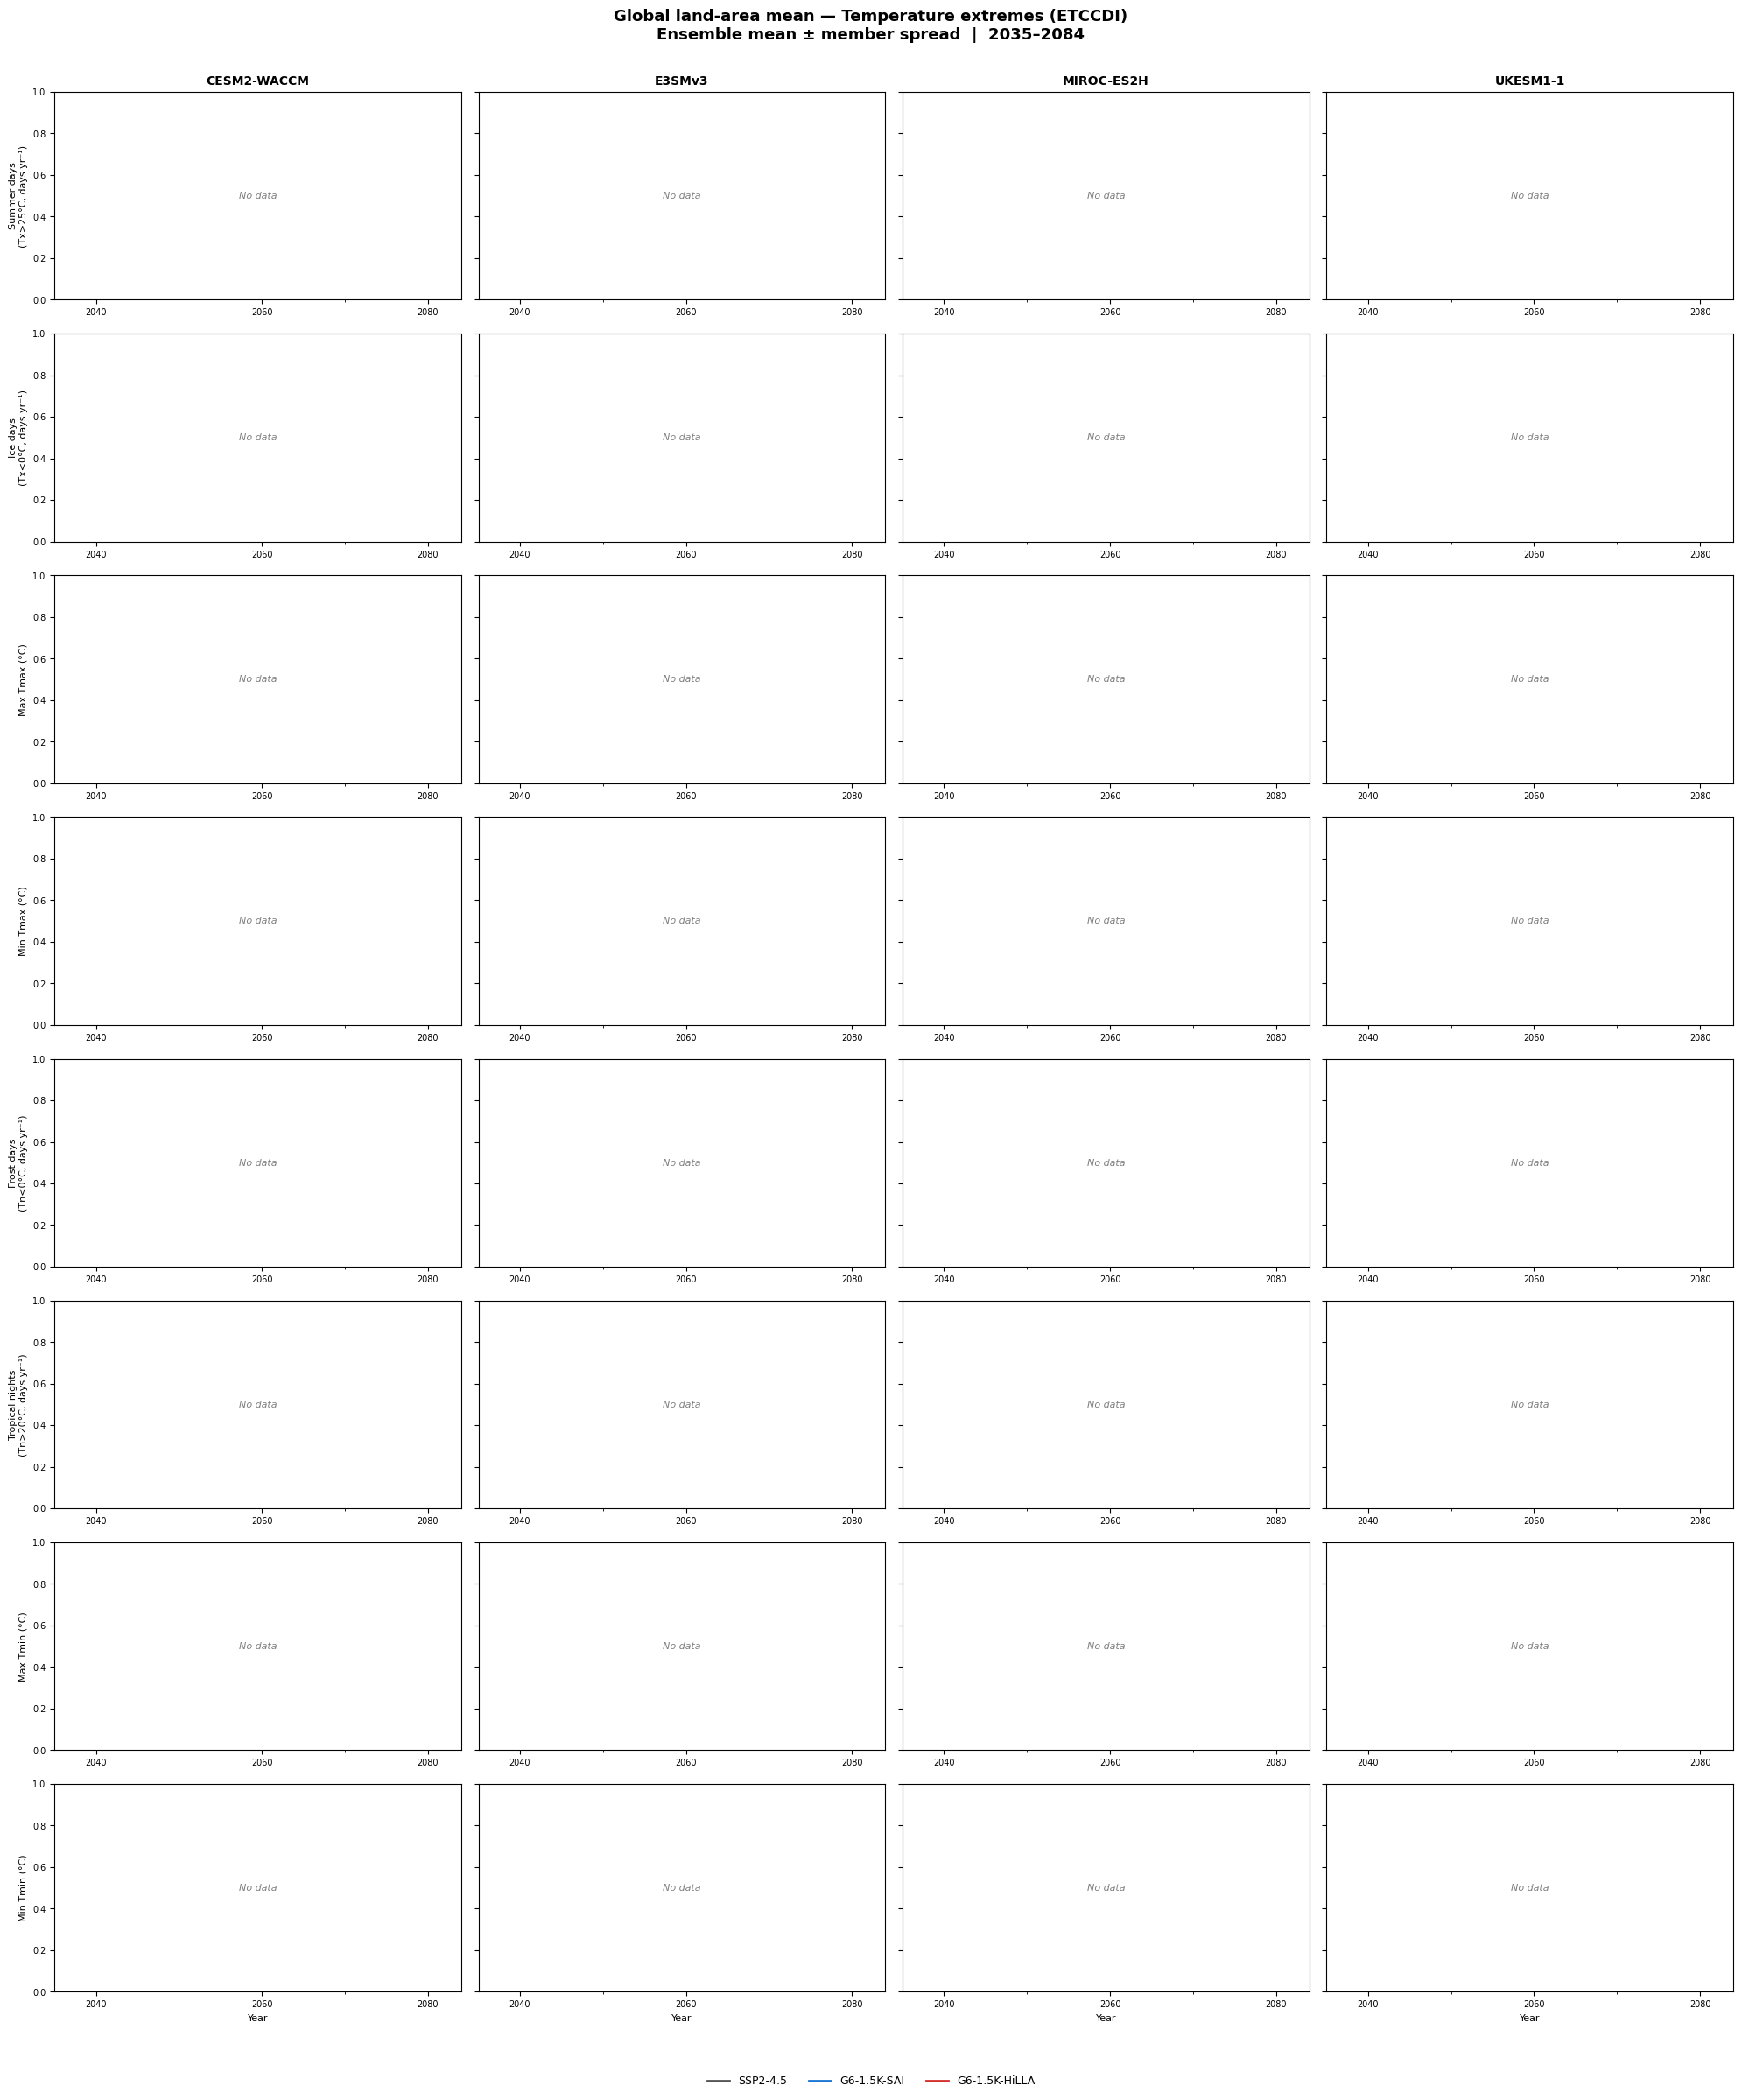

Saved: fig1_temperature_indices_timeseries.png


In [10]:
n_idx = len(TEMP_INDICES)   # 8
n_mod = len(MODELS)          # 4

fig, axes = plt.subplots(
    n_idx, n_mod,
    figsize=(5 * n_mod, 3 * n_idx),
    sharey='row',
)
fig.suptitle(
    'Global land-area mean — Temperature extremes (ETCCDI)\n'
    'Ensemble mean ± member spread  |  2035–2084',
    fontsize=13, fontweight='bold', y=0.995,
)

for row, (idx, label) in enumerate(TEMP_INDICES):
    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        plotted_any = False

        for scen_key, scen_display in MODEL_SCENARIOS[model]:
            result = temp_cache.get((model, scen_key, idx))
            if result is None:
                continue
            years, ens_mean, ens_min, ens_max = result
            color = SCENARIO_COLORS[scen_display]
            ax.plot(years, ens_mean, color=color, lw=1.5)
            ax.fill_between(years, ens_min, ens_max, color=color, alpha=0.25, lw=0)
            plotted_any = True

        ax.set_xlim(2035, 2084)
        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(plt.MultipleLocator(20))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(10))

        if not plotted_any:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey', style='italic')

        if row == 0:
            ax.set_title(model, fontsize=10, fontweight='bold', pad=6)
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == n_idx - 1:
            ax.set_xlabel('Year', fontsize=8)

# Shared legend below all subplots
legend_handles = [
    Line2D([0], [0], color=SCENARIO_COLORS[s], lw=2, label=s)
    for s in ('SSP2-4.5', 'G6-1.5K-SAI', 'G6-1.5K-HiLLA')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, 0.001),
)
plt.tight_layout(rect=[0, 0.03, 1, 0.992])

plt.savefig('example_figs/fig1_temperature_indices_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_temperature_indices_timeseries.png")


In [ ]:
n_idx = len(PRECIP_INDICES)  # 8
n_mod = len(MODELS)           # 4

fig, axes = plt.subplots(
    n_idx, n_mod,
    figsize=(5 * n_mod, 3 * n_idx),
    sharey='row',
)
fig.suptitle(
    'Global land-area mean — Precipitation extremes (ETCCDI)\n'
    'Ensemble mean ± member spread  |  2035–2084',
    fontsize=13, fontweight='bold', y=0.995,
)

for row, (idx, label) in enumerate(PRECIP_INDICES):
    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        plotted_any = False

        for scen_key, scen_display in MODEL_SCENARIOS[model]:
            result = precip_cache.get((model, scen_key, idx))
            if result is None:
                continue
            years, ens_mean, ens_min, ens_max = result
            color = SCENARIO_COLORS[scen_display]
            ax.plot(years, ens_mean, color=color, lw=1.5)
            ax.fill_between(years, ens_min, ens_max, color=color, alpha=0.25, lw=0)
            plotted_any = True

        ax.set_xlim(2035, 2084)
        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_locator(plt.MultipleLocator(20))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(10))

        if not plotted_any:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey', style='italic')

        if row == 0:
            ax.set_title(model, fontsize=10, fontweight='bold', pad=6)
        if col == 0:
            ax.set_ylabel(label, fontsize=8)
        if row == n_idx - 1:
            ax.set_xlabel('Year', fontsize=8)

# Shared legend below all subplots
legend_handles = [
    Line2D([0], [0], color=SCENARIO_COLORS[s], lw=2, label=s)
    for s in ('SSP2-4.5', 'G6-1.5K-SAI', 'G6-1.5K-HiLLA')
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, 0.001),
)
plt.tight_layout(rect=[0, 0.03, 1, 0.992])

plt.savefig('fig2_precipitation_indices_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_precipitation_indices_timeseries.png")
